# Notebook 1 — Loading the Svedala Grid

**Course: Cross-Corridor Capacity Analysis with pandapower (Svedala grid)**

Welcome. By the end of this six-notebook series you will have built a working
**cross-corridor capacity analysis tool** for the Svedala transmission grid — the simplified Nordic-style
test model from KTH-EPE.

## Background — where the model comes from

The Svedala model originates as a **CIM CGMES** dataset (the standard ENTSO-E
exchange format for transmission grids). The KTH-EPE notebook
`Pandapower_CIM_import.ipynb`
(<https://github.com/KTH-EPE/CIM_exportimport>) ingests those XML files and
produces a pandapower network. The *simplified* version of that network is
what we use here, exported as five CSV files — one per element table.

## Learning objectives

- Reconstitute a pandapower network from the five CSVs.
- Inspect the four bidding zones (`ZON_NORR`, `ZON_MITT`, `ZON_SYDVÄST`, `ZON_EXTERN`).
- Map the topology with the real geographic coordinates the CIM model carries.

## 1.1  Setup

Make sure you have these CSVs in `data/` next to this notebook:
`buses.csv`, `lines.csv`, `transformers.csv`, `generators.csv`, `loads.csv`.

If you don't, clone <https://github.com/KTH-EPE/CIM_exportimport>, run
`Pandapower_CIM_import.ipynb`, and copy the contents of its `Svedala_csv/`
folder into your `data/` folder.

In [25]:
import pandapower as pp
import pandas as pd
import matplotlib.pyplot as plt
from svedala_loader import load_svedala     # shared helper

print(f'pandapower version: {pp.__version__}')

pandapower version: 3.4.0


## 1.2  Load the network

`load_svedala()` reads the five CSVs into the corresponding pandapower
DataFrames (`net.bus`, `net.line`, `net.trafo`, `net.gen`, `net.load`) and applies
two fix-ups:

1. **Line ratings:** the simplified model has empty `max_i_ka`. The loader
   fills in conservative typical Nordic values per voltage level (1700 MVA at
   400 kV, 570 MVA at 220 kV, 220 MVA at 135 kV).
2. **Slack check:** confirms exactly one generator has `slack=True` (this
   model uses a slack generator instead of an `ext_grid`).

Open `svedala_loader.py` to see the full source.

In [26]:
net = load_svedala('../data')
print(net)

This pandapower network includes the following parameter tables:
   - bus (52 elements)
   - load (60 elements)
   - gen (36 elements)
   - line (52 elements)
   - trafo (44 elements)


## 1.3  Element tables

Every pandapower network exposes its components as DataFrames. Take a look:

In [27]:
# Buses - notice the zone column is already populated by the CIM import
net.bus[['name', 'vn_kv', 'zone']].head(10)

,name,vn_kv,zone
0,AGGAN CT11_135.0kV,135.0,AGGAN CT11
18,AGGAN CT11_400.0kV,400.0,AGGAN CT11
51,AGGAN CT11_17.0kV,17.0,AGGAN CT11
69,ATOMSBERG FT61_400.0kV,400.0,ATOMSBERG FT61
93,ATOMSBERG FT61_20.0kV,20.0,ATOMSBERG FT61
99,BLOCKET FT51_400.0kV,400.0,BLOCKET FT51
128,BLOCKET FT51_20.0kV,20.0,BLOCKET FT51
130,DALBO FT41_400.0kV,400.0,DALBO FT41
166,DALBO FT41_17.0kV,17.0,DALBO FT41
167,ERIKSHAMN FT47_400.0kV,400.0,ERIKSHAMN FT47


In [28]:
# Lines
net.line[['name', 'from_bus', 'to_bus', 'r_ohm_per_km', 'x_ohm_per_km',
          'max_i_ka', 'in_service']].head(10)

,name,from_bus,to_bus,r_ohm_per_km,x_ohm_per_km,max_i_ka,in_service
0,RL1,266,509,6.422490,47.31939,0.95,True
1,CL5,866,297,8.000000,80.00000,2.50,True
3,CL17,1014,346,16.000000,106.72000,2.50,True
5,RL7,266,936,8.449110,50.70013,0.95,True
6,CL13,729,1014,1.600000,16.00000,2.50,True
8,CL4,18,866,1.600000,12.80000,2.50,True
9,CL10,802,729,6.400000,64.00000,2.50,True
10,CL8,866,802,6.400000,56.00000,2.50,True
12,FL5,434,167,1.600000,24.00000,2.50,True
15,RL3,1132,509,1.689458,13.51931,0.95,True


In [29]:
# Transformers
net.trafo[['name', 'hv_bus', 'lv_bus', 'sn_mva',
           'vn_hv_kv', 'vn_lv_kv', 'in_service']].head(10)

,name,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,in_service
0,FT63_T12,899,928,750.0,400.0,20.0,True
1,YTTERFORSEN_G1_TRAFO,1132,1131,200.0,135.0,17.0,True
3,HÄLLAN_G4_TRAFO,219,254,750.0,400.0,17.0,True
4,RUTHUVUD_G1_TRAFO,642,684,600.0,400.0,20.0,True
6,CT11_T2,18,51,500.0,400.0,17.0,True
7,STUPET_G4_TRAFO,842,895,500.0,135.0,17.0,True
8,FT47_T11,167,190,800.0,400.0,20.0,True
9,RUTHUVUD_G2_TRAFO,642,684,200.0,400.0,20.0,True
10,STUPET_G3_TRAFO,842,895,300.0,135.0,17.0,True
11,FT44_T12,346,390,250.0,400.0,20.0,True


In [30]:
# Generators - 'type' tells you Hydro vs Thermal, 'slack' marks the slack
net.gen[['name', 'bus', 'type', 'p_mw', 'min_p_mw',
         'max_p_mw', 'slack']].head(15)

,name,bus,type,p_mw,min_p_mw,max_p_mw,slack
0,AGGAN_G1,51,Hydro,200.3918,0.0,380.0,False
1,AGGAN_G2,51,Hydro,364.6877,0.0,570.0,False
2,ATOMSBERG_G1,93,Thermal,-0.0000,0.0,180.0,False
3,BLOCKET_G1,128,Thermal,600.7217,0.0,630.0,False
4,BLOCKET_G2,128,Thermal,400.7217,0.0,630.0,False
5,ERIKSHAMN_G1,190,Thermal,539.6186,0.0,540.0,False
6,ERIKSHAMN_G2,190,Thermal,539.6186,0.0,540.0,False
8,HÄLLAN_G1,254,Hydro,880.3918,0.0,1350.0,True
9,HÄLLAN_G2,254,Hydro,801.3918,0.0,1350.0,False
10,HÄLLAN_G3,254,Hydro,200.7372,0.0,715.0,False


In [31]:
# Loads
net.load[['name', 'bus', 'p_mw', 'q_mvar']].head(10)

,name,bus,p_mw,q_mvar
0,AT111_T1_LAST,1088,75.0,30.00
1,AT111_T2_LAST,1088,25.0,10.00
2,AT241_T1_LAST,486,150.0,37.50
3,AT241_T2_LAST,486,50.0,12.50
4,CT11_T1_LAST,0,150.0,60.00
5,CT11_T2_LAST,0,50.0,20.00
6,CT12_T1_LAST,842,225.0,75.00
7,CT12_T2_LAST,842,75.0,25.00
8,CT22_T1_LAST,778,210.0,71.25
9,CT22_T2_LAST,778,70.0,23.75


## 1.4  Zones — the four bidding zones

The CIM importer carries the **SubGeographicalRegion** of each bus into the
`zone` column. The Svedala model uses four zones that correspond loosely to
the Swedish bidding zones SE1–SE4:

| Zone           | Character                                     |
|----------------|-----------------------------------------------|
| `ZON_NORR`     | North Sweden — hydro-dominated, surplus       |
| `ZON_MITT`     | Central Sweden — mixed generation, large load |
| `ZON_SYDVÄST`  | South-west Sweden — thermal, deficit          |
| `ZON_EXTERN`   | External boundary equivalent (slack lives here) |

In [32]:
# Bus and generator counts per zone
import pandas as pd
summary = pd.DataFrame({
    'buses_per_zone':       net.bus.zone.value_counts(),
    'gen_pmax_total_mw':    net.gen.groupby(net.bus.loc[net.gen.bus, 'zone'].values).max_p_mw.sum(),
    'load_p_total_mw':      net.load.groupby(net.bus.loc[net.load.bus, 'zone'].values).p_mw.sum(),
})
summary.fillna(0).round(0)

,buses_per_zone,gen_pmax_total_mw,load_p_total_mw
AGGAN CT11,3,950.0,200.0
ATOMSBERG FT61,2,180.0,500.0
BLOCKET FT51,2,1260.0,800.0
DALBO FT41,2,0.0,540.0
ERIKSHAMN FT47,2,1080.0,100.0
HÄLLAN CT72,2,4130.0,2000.0
HÄSTSJÖ RT132,2,540.0,306.0
JAURAS CT71,2,475.0,300.0
KÄRNAN FT44,2,990.0,400.0
MITTLANDA FT45,1,0.0,700.0


## 1.5  Map the topology

The CIM model carries real geographic coordinates (lat/lon) in `net.bus.geo`
as GeoJSON strings. We extract them and plot the topology over a simple
lat/lon grid — substations colour-coded by zone.

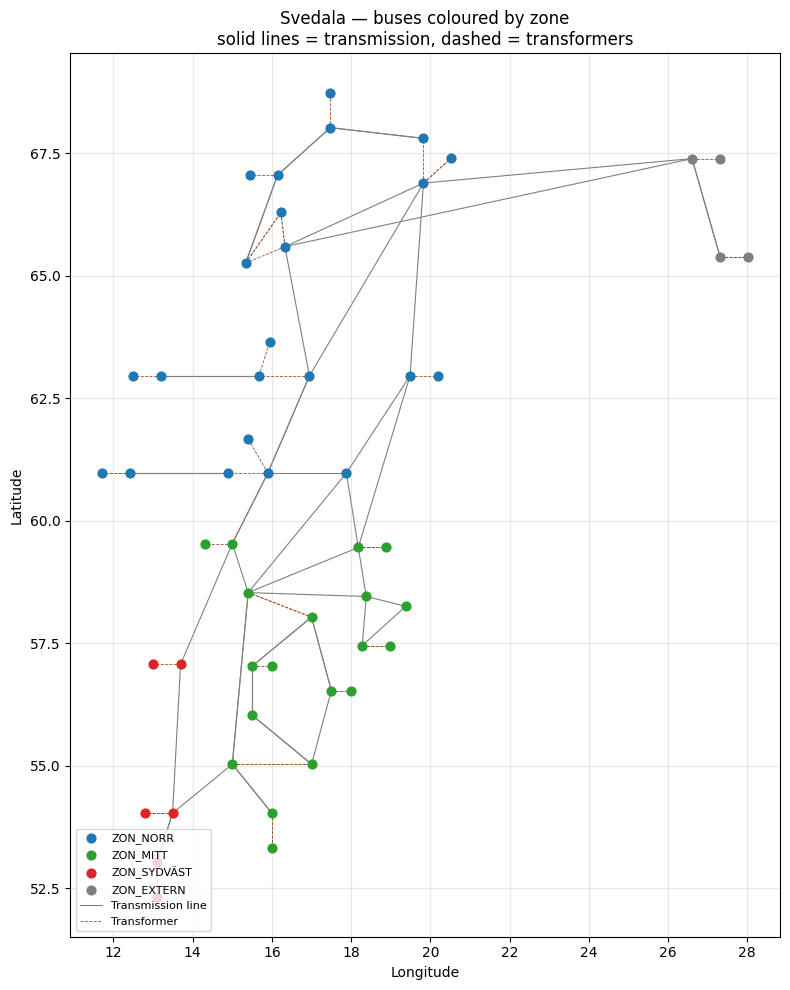

In [33]:
import json as _json
import numpy as np
from matplotlib.lines import Line2D

def extract_coords(geo_str):
    if pd.isna(geo_str): return (None, None)
    obj = _json.loads(geo_str)
    lon, lat = obj['coordinates']
    return (lon, lat)

coords = net.bus.geo.apply(extract_coords)
net.bus['lon'] = [c[0] for c in coords]
net.bus['lat'] = [c[1] for c in coords]

ZONE_COLOR = {'ZON_NORR':    '#1f77b4',
              'ZON_MITT':    '#2ca02c',
              'ZON_SYDVÄST': '#d62728',
              'ZON_EXTERN':  '#7f7f7f'}

fig, ax = plt.subplots(figsize=(8, 10))
for zone, color in ZONE_COLOR.items():
    sub = net.bus[net.bus.SubGeographicalRegion_name == zone]
    ax.scatter(sub.lon, sub.lat, c=color, label=zone, s=40, zorder=3)

# Draw transmission lines
for _, ln in net.line.iterrows():
    fb, tb = ln.from_bus, ln.to_bus
    ax.plot([net.bus.at[fb,'lon'], net.bus.at[tb,'lon']],
            [net.bus.at[fb,'lat'], net.bus.at[tb,'lat']],
            color='gray', linewidth=0.8, zorder=1)

# Draw transformers (dashed) — each substation has buses at multiple voltage
# levels with slightly offset CIM schematic coordinates; without these links
# the lower-voltage buses appear as disconnected islands.
for _, tr in net.trafo.iterrows():
    hb, lb = tr.hv_bus, tr.lv_bus
    ax.plot([net.bus.at[hb,'lon'], net.bus.at[lb,'lon']],
            [net.bus.at[hb,'lat'], net.bus.at[lb,'lat']],
            color='sienna', linewidth=0.6, linestyle='--', zorder=2)

# Build legend: zone scatter handles + line type handles
handles, labels = ax.get_legend_handles_labels()
handles += [
    Line2D([0], [0], color='gray',   linewidth=0.8, linestyle='-',  label='Transmission line'),
    Line2D([0], [0], color='sienna', linewidth=0.6, linestyle='--', label='Transformer'),
]
labels += ['Transmission line', 'Transformer']

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Svedala — buses coloured by zone\nsolid lines = transmission, dashed = transformers')
ax.legend(handles=handles, labels=labels, loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 1.6  Save the verified network

Save the loaded network to a JSON file so the next notebooks can start from a
single canonical source rather than re-loading from CSV.

In [34]:
pp.to_json(net, '../data/svedala.json')
print('Saved ../data/svedala.json')

Saved ../data/svedala.json


## 1.7  Exercises

1. How many lines are at 400 kV? At 220 kV? At 135 kV? Use `net.bus.vn_kv` and
   join with `net.line.from_bus`.
2. Which **substation** has the largest installed generation capacity
   (sum of `max_p_mw` across all generators at any bus belonging to it)?
   Hint: substation name comes from `net.bus.zone` is *not* the substation —
   look at the `name` column of the bus, e.g. `'BLOCKET FT51_400.0kV'` and
   strip the trailing `'_<voltage>kV'`.
3. Sum the load per zone (in MW) and compare with the total generation per
   zone. Which zones are *exporters* of power and which are *importers*?

In [35]:
# Exercise 1 — Line counts per voltage level
# Join each line's from_bus to the bus table to get the nominal voltage.
line_vn = net.line.join(net.bus[['vn_kv']], on='from_bus')
#print(line_vn.vn_kv)
#counts = line_vn.groupby('vn_kv').size().rename('line_count')
print(counts.to_string())


vn_kv
135.0    17
220.0     2
400.0    33


In [36]:
# Exercise 2 — Substation with largest installed generation capacity
# Strip the trailing '_<voltage>kV' suffix from bus names to get the substation name.
bus_sub = net.bus['name'].str.replace(r'_\d+\.?\d*kV$', '', regex=True).rename('substation')

# Map each generator's bus to its substation name, then sum max_p_mw.
gen_sub = net.gen.join(bus_sub, on='bus')
top = gen_sub.groupby('substation')['max_p_mw'].sum().sort_values(ascending=False)
print(top.head(10).to_string())
print(f"\nLargest: {top.idxmax()}  ({top.max():.0f} MW)")


substation
HÄLLAN CT72         4130.0
STUPET CT12         1520.0
BLOCKET FT51        1260.0
SYDBÄCK FT63        1080.0
ERIKSHAMN FT47      1080.0
KÄRNAN FT44          990.0
AGGAN CT11           950.0
RUTHUVUD FT62        900.0
NORRSELE AT241       790.0
OLMÅFALLET AT121     665.0

Largest: HÄLLAN CT72  (4130 MW)


In [37]:
# Exercise 3 — Exporting vs importing zones
bus_zone = net.bus['SubGeographicalRegion_name'].rename('zone')

load_by_zone = (net.load
                .join(bus_zone, on='bus')
                .groupby('zone')['p_mw'].sum()
                .rename('load_mw'))

gen_by_zone  = (net.gen
                .join(bus_zone, on='bus')
                .groupby('zone')['max_p_mw'].sum()
                .rename('gen_capacity_mw'))

balance = pd.concat([gen_by_zone, load_by_zone], axis=1).fillna(0)
balance['net_export_mw'] = balance['gen_capacity_mw'] - balance['load_mw']
balance['role'] = balance['net_export_mw'].apply(lambda x: 'Exporter' if x > 0 else 'Importer')
print(balance.round(0).to_string())


             gen_capacity_mw  load_mw  net_export_mw      role
zone                                                          
ZON_EXTERN            4605.0   2300.0         2305.0  Exporter
ZON_MITT              4050.0   6111.0        -2061.0  Importer
ZON_NORR              5920.0   1180.0         4740.0  Exporter
ZON_SYDVÄST           2160.0   1390.0          770.0  Exporter


---

✅ **Checkpoint reached.** The Svedala grid is loaded, zoned and visualized.

Continue to [Notebook 2 — Base Case Power Flow](02_base_case_powerflow.ipynb).